# Time series — scénario `reality_access`

Construit `Time_series.csv` par cluster pour **reality_access**. Les profils `ELECTRICITY` et
`SPACE_COOLING` sont une **somme pondérée par les énergies annuelles**, renormalisée à somme 1 :

$$p_{\text{access}} = \frac{E_A\,\text{forme}_A + E_{B+C}\,\text{forme}_{B+C}}{E_A + E_{B+C}}$$

| Terme | Énergie (poids) | Forme horaire | Provenance |
|---|---|---|---|
| **A** — réseau | $E_A$ = Source A (AETN), GWh utile/an | $\text{forme}_A$ | `reality/output_energyscope/C{k}/Time_series.csv` |
| **B+C** — hors réseau + non électrifiés | $E_{B+C}$ = (B+C) sufficiency | $\text{forme}_{B+C}$ | RAMP `sufficiency` proratisé $f=HH_{B+C}/HH_{tot}$ |

Toutes les énergies et le facteur $f$ proviennent de `demande_access.ipynb` (via `%run`), sans
valeur en dur ni cellule dupliquée.

> **⚠ Limitation documentée — `forme_A`.** La Source A (réseau, ~180 GWh/an) n'a **aucun profil
> horaire propre** dans les données (mesures AETN annuelles uniquement). On lui applique donc la
> **forme normalisée du scénario `reality`**, elle-même issue de RAMP reality (courbe de la Source B :
> ménages hors réseau + services informels, ~3 GWh). C'est une **approximation assumée** — une vraie
> courbe de charge du distributeur (profil mensuel AETN) serait une amélioration séparée, hors périmètre.
>
> **Contrainte impérative :** cette même `forme_A` doit servir dans `reality`, `reality_phase2` et
> `reality_access`. Ici elle est **lue directement** du fichier `reality` → identique par construction.
> Si elle divergeait entre scénarios, le delta d'accès mélangerait un changement de profil avec l'effet
> de l'accès, et le chiffre phare deviendrait ininterprétable.
>
> **Pas de double comptage.** Seule l'énergie $E_A$ (Source A) pondère $\text{forme}_A$ ; l'énergie de
> la **Source B reality n'est jamais ajoutée** — dans access, B est intégralement porté par le terme
> sufficiency B+C. (`forme_A` contient le *motif* temporel de B reality, mais son *énergie* vaut $E_A$,
> pas $E_A + E_B$.)

Les colonnes mobilité et facteurs de capacité renouvelables (`PV`, `WIND_*`, `SOLAR`, `HYDRO_*`,
`TIDAL`, `CSP`) ne dépendent **pas** de la demande : reprises telles quelles des `Time_series.csv`
`sufficiency`. Sortie : `output_energyscope/C{k}/Time_series.csv`, distincte de `reality` et `sufficiency`.

## 1. Configuration — réutilise `demande_access.ipynb`

In [1]:
%%capture
# Importe toute la configuration et les énergies du notebook Demandes access
# (CLUSTERS, MUNI_TO_CLUSTER, FACTOR, source_a_by_cluster, bc_by_cluster,
#  source_b_reality_by_cluster, hh, pd, os …) sans dupliquer de cellule ni coder de valeur en dur.
import numpy as np
import matplotlib.pyplot as plt
%run demande_access.ipynb

In [2]:
RAMP_SUFF_DIR  = "../sufficiency/data ramp"
REALITY_TS_DIR = "../reality/output_energyscope"
SUFF_TS_DIR    = "../sufficiency/output_energyscope"
OUTPUT_DIR     = "output_energyscope"

# Colonnes RAMP sufficiency formant les profils (identiques à sufficiency/time_series.ipynb)
SUFF_ELECTRICITY_COLS = [
    "sufficiency_illumination", "sufficiency_ICT", "sufficiency_cold_storage",
    "sufficiency_thermal_comfort", "public_lighting_illumination",
    "big_school_illumination", "big_school_ICT", "big_school_cold_storage",
    "big_school_space_cooling",
    "health_center_illumination", "health_center_ICT", "health_center_cold_storage",
    "health_center_space_cooling", "health_center_water_supply", "health_center_medical_equip",
    "entertainment_business_illumination", "entertainment_business_ICT",
    "entertainment_business_cold_storage",
    "restaurant_illumination", "restaurant_cold_storage", "restaurant_kitchen",
    "store_illumination", "store_ICT", "store_cold_storage",
    "workshop_illumination", "workshop_ICT", "workshop_machinery",
    "rice_processing_rice_processing",
]
SUFF_SPACE_COOLING_COLS = [
    "sufficiency_thermal_comfort",
    "big_school_space_cooling",
    "health_center_space_cooling",
]

# Énergies annuelles par cluster reprises de demande_access (GWh utile/an)
E_A  = {k: sum(v.values()) for k, v in source_a_by_cluster.items()}      # Source A seule (AETN)
E_BC = {k: sum(v.values()) for k, v in bc_by_cluster.items()}           # (B+C) sufficiency

print(f"Config importée de demande_access.ipynb : {len(CLUSTERS)} clusters, "
      f"{len(FACTOR)} municipalités.")

Config importée de demande_access.ipynb : 5 clusters, 21 municipalités.


## 2. Fonctions — une fonction = une étape

- `load_ramp_hourly` — RAMP sufficiency d'une municipalité → 8760 moyennes horaires (moyenne 60 min).
- `bc_profile` — watts RAMP sufficiency proratisés par $f_{muni}$ (comme `demande_access`), agrégés, normalisés.
- `unit` / `blend` — normalisation à somme 1 et somme pondérée par les énergies annuelles.

In [3]:
def load_ramp_hourly(muni, cols):
    """RAMP sufficiency d'une municipalité -> moyennes horaires (8760 lignes)."""
    path = f"{RAMP_SUFF_DIR}/{muni}/load_curve_energy_service_full_year_Norte_Amazonia.csv"
    available = pd.read_csv(path, nrows=0).columns.tolist()
    valid = [c for c in cols if c in available]
    df = pd.read_csv(path, usecols=valid).fillna(0)
    return pd.DataFrame({c: df[c].values.reshape(8760, 60).mean(axis=1) for c in valid})


def bc_profile(munis, cols):
    """forme_BC : watts RAMP sufficiency proratises par f_muni, agreges, normalises (somme = 1)."""
    total = np.zeros(8760)
    for muni in munis:
        total += FACTOR[muni] * load_ramp_hourly(muni, cols).sum(axis=1).values
    return total / total.sum()


def unit(x):
    """Renormalise un profil a somme 1."""
    x = np.asarray(x, dtype=float)
    return x / x.sum()


def blend(forme_a, forme_bc, e_a, e_bc):
    """Somme ponderee E_A*forme_A + E_BC*forme_BC, renormalisee a somme 1.
    E_A = Source A seule : l'energie de la Source B reality n'est jamais ajoutee (pas de double comptage)."""
    mix = e_a * unit(forme_a) + e_bc * unit(forme_bc)
    return mix / mix.sum()

## 3. Vérification — poids A vs B+C par cluster

Les poids sont les énergies annuelles de `demande_access`. Contrôle indépendant : on recharge
`demands_access_by_provenance.csv` (écrit par `demande_access`) et on compare colonne par colonne.
On affiche aussi la Source B reality pour rappeler qu'elle est **exclue** de la pondération.

In [4]:
prov = pd.read_csv(f"{OUTPUT_DIR}/demands_access_by_provenance.csv")
prov["k"] = prov["Cluster"].str[1:].astype(int)
disk = prov.groupby("k")[["A_réseau_reality", "BC_sufficiency"]].sum()

rows = []
for k in sorted(CLUSTERS):
    ea, ebc = E_A[k], E_BC[k]
    rows.append({"Cluster": f"C{k}", "E_A_GWh": ea, "E_BC_GWh": ebc,
                 "poids_A": ea / (ea + ebc), "poids_BC": ebc / (ea + ebc)})
weights = pd.DataFrame(rows)

print("Poids des composantes par cluster (énergies GWh utile/an, reprises de demande_access)")
print(weights.to_string(index=False, formatters={
    "E_A_GWh": "{:8.4f}".format, "E_BC_GWh": "{:8.4f}".format,
    "poids_A": "{:.4f}".format, "poids_BC": "{:.4f}".format}))

# Les énergies en mémoire doivent égaler celles écrites sur disque par demande_access
for k in sorted(CLUSTERS):
    assert abs(E_A[k]  - disk.loc[k, "A_réseau_reality"]) < 1e-9, f"C{k} E_A mismatch vs disk"
    assert abs(E_BC[k] - disk.loc[k, "BC_sufficiency"])  < 1e-9, f"C{k} E_BC mismatch vs disk"
assert np.allclose(weights["poids_A"] + weights["poids_BC"], 1.0)
print("\n✓ Poids = énergies Demands access (contrôle sur demands_access_by_provenance.csv)")

# Rappel : la Source B reality n'entre PAS dans la pondération (portée par le terme B+C sufficiency)
b_reality = sum(sum(v.values()) for v in source_b_reality_by_cluster.values())
print(f"→ Source B reality = {b_reality:.2f} GWh utile — EXCLUE de la pondération (pas de double comptage).")

Poids des composantes par cluster (énergies GWh utile/an, reprises de demande_access)
Cluster  E_A_GWh E_BC_GWh poids_A poids_BC
     C1  11.4018   7.9271  0.5899   0.4101
     C2   0.2721   1.0269  0.2094   0.7906
     C3  90.6238  10.2395  0.8985   0.1015
     C4  23.6977  12.7300  0.6505   0.3495
     C5  55.3653   1.0182  0.9819   0.0181

✓ Poids = énergies Demands access (contrôle sur demands_access_by_provenance.csv)
→ Source B reality = 2.20 GWh utile — EXCLUE de la pondération (pas de double comptage).


## 4. Construction des `Time_series.csv`

Base = `Time_series.csv` `sufficiency` (mobilité + facteurs de capacité renouvelables, inchangés) ;
seules `ELECTRICITY` et `SPACE_COOLING` sont remplacées par la somme pondérée
$E_A\cdot\text{forme}_A + E_{B+C}\cdot\text{forme}_{B+C}$.

In [5]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
PROFILE_COLS = ["ELECTRICITY", "SPACE_COOLING"]
ts_access = {}

for k, munis in CLUSTERS.items():
    # forme_A : forme horaire empruntée par la Source A = profil du scénario reality (issu de RAMP).
    # Lue directement du fichier reality -> IDENTIQUE à reality par construction (contrainte impérative).
    forme_A = pd.read_csv(f"{REALITY_TS_DIR}/C{k}/Time_series.csv", sep=";", index_col=0)
    ts      = pd.read_csv(f"{SUFF_TS_DIR}/C{k}/Time_series.csv", sep=";", index_col=0)  # base sufficiency
    ts.index.name = ""

    # Somme pondérée E_A*forme_A + E_BC*forme_BC(sufficiency). E_A = Source A seule :
    # l'énergie de la Source B reality n'est JAMAIS ajoutée (B est portée par forme_BC).
    ts["ELECTRICITY"]   = blend(forme_A["ELECTRICITY"].values,
                                bc_profile(munis, SUFF_ELECTRICITY_COLS),   E_A[k], E_BC[k])
    ts["SPACE_COOLING"] = blend(forme_A["SPACE_COOLING"].values,
                                bc_profile(munis, SUFF_SPACE_COOLING_COLS), E_A[k], E_BC[k])

    out_path = f"{OUTPUT_DIR}/C{k}/Time_series.csv"
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    ts.to_csv(out_path, sep=";")
    ts_access[k] = ts
    print(f"Cluster {k} ({len(munis)} municipalités) → {out_path}")

Cluster 1 (4 municipalités) → output_energyscope/C1/Time_series.csv


Cluster 2 (1 municipalités) → output_energyscope/C2/Time_series.csv


Cluster 3 (3 municipalités) → output_energyscope/C3/Time_series.csv


Cluster 4 (12 municipalités) → output_energyscope/C4/Time_series.csv


Cluster 5 (1 municipalités) → output_energyscope/C5/Time_series.csv


## 5. Vérification — normalisation (somme = 1, tolérance 1e-9)

In [6]:
TOL = 1e-9
print("Vérification — profils normalisés (somme attendue = 1.0)")
for k in CLUSTERS:
    ts = pd.read_csv(f"{OUTPUT_DIR}/C{k}/Time_series.csv", sep=";", index_col=0)
    for col in PROFILE_COLS:
        s = ts[col].sum()
        assert abs(s - 1.0) < TOL, f"C{k} {col} somme={s}"
        print(f"  C{k} {col:<14} somme = {s:.12f}")
print("\n✓ Tous les profils ELECTRICITY et SPACE_COOLING somment à 1.0 (tol 1e-9)")

Vérification — profils normalisés (somme attendue = 1.0)
  C1 ELECTRICITY    somme = 1.000000000000
  C1 SPACE_COOLING  somme = 1.000000000000
  C2 ELECTRICITY    somme = 1.000000000000
  C2 SPACE_COOLING  somme = 1.000000000000
  C3 ELECTRICITY    somme = 1.000000000000
  C3 SPACE_COOLING  somme = 1.000000000000
  C4 ELECTRICITY    somme = 1.000000000000
  C4 SPACE_COOLING  somme = 1.000000000000
  C5 ELECTRICITY    somme = 1.000000000000
  C5 SPACE_COOLING  somme = 1.000000000000

✓ Tous les profils ELECTRICITY et SPACE_COOLING somment à 1.0 (tol 1e-9)


## 6. Vérification — `forme_A` identique à `reality` (contrainte impérative)

On retire du profil access la part `forme_BC` pondérée par `E_BC` : ce qui reste doit être
exactement `forme_A` = le profil `reality` normalisé. Garantit qu'access n'a pas altéré la forme A.

In [7]:
print("Vérification — forme_A implicite dans access == profil reality normalisé")
for k, munis in CLUSTERS.items():
    acc = ts_access[k]["ELECTRICITY"].values
    forme_bc = bc_profile(munis, SUFF_ELECTRICITY_COLS)
    forme_a_reality = unit(pd.read_csv(f"{REALITY_TS_DIR}/C{k}/Time_series.csv",
                                       sep=";", index_col=0)["ELECTRICITY"].values)
    # access = (E_A*forme_A + E_BC*forme_bc)/(E_A+E_BC)  ->  forme_A implicite
    forme_a_impl = (acc * (E_A[k] + E_BC[k]) - E_BC[k] * forme_bc) / E_A[k]
    err = np.abs(forme_a_impl - forme_a_reality).max()
    assert err < 1e-9, f"C{k}: forme_A a dérivé vs reality (écart {err:.2e})"
    print(f"  C{k}: écart max forme_A(access) vs forme_A(reality) = {err:.2e}")
print("\n✓ forme_A est bien celle de reality — le delta d'accès reste interprétable.")

Vérification — forme_A implicite dans access == profil reality normalisé


  C1: écart max forme_A(access) vs forme_A(reality) = 8.13e-20


  C2: écart max forme_A(access) vs forme_A(reality) = 2.44e-19


  C3: écart max forme_A(access) vs forme_A(reality) = 5.42e-20


  C4: écart max forme_A(access) vs forme_A(reality) = 8.13e-20


  C5: écart max forme_A(access) vs forme_A(reality) = 5.42e-20

✓ forme_A est bien celle de reality — le delta d'accès reste interprétable.


## 7. Vérification visuelle — jour type avant / après (C2 et C4)

C2 et C4 sont les clusters où B+C pèse le plus. Profil `ELECTRICITY` moyen d'un jour type
(moyenne sur les 365 jours) : `forme_A` (reality, empruntée par A) vs `reality_access` (somme pondérée).

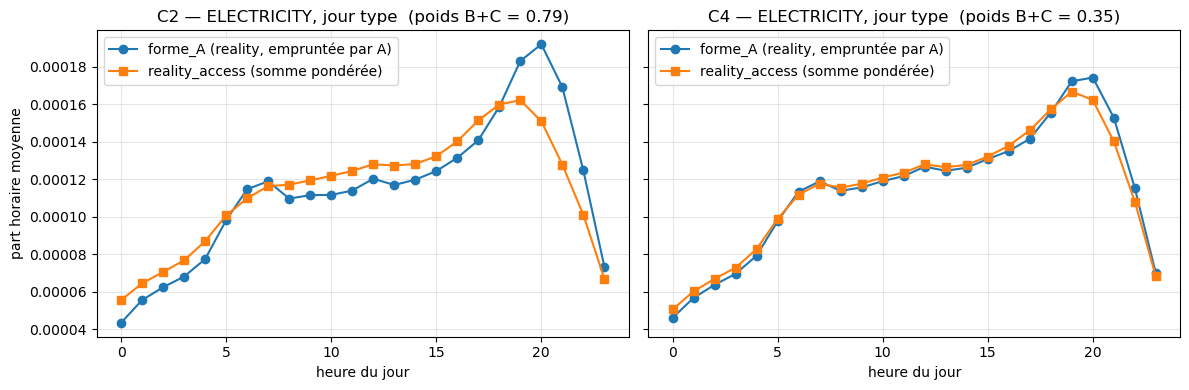

In [8]:
def daily_mean(profile):
    """Profil moyen d'un jour type : moyenne sur les 365 jours (8760 = 365 x 24)."""
    return np.asarray(profile, dtype=float).reshape(365, 24).mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, k in zip(axes, [2, 4]):
    forme_A = pd.read_csv(f"{REALITY_TS_DIR}/C{k}/Time_series.csv", sep=";", index_col=0)
    ax.plot(range(24), daily_mean(unit(forme_A["ELECTRICITY"].values)), "o-",
            label="forme_A (reality, empruntée par A)")
    ax.plot(range(24), daily_mean(ts_access[k]["ELECTRICITY"].values), "s-",
            label="reality_access (somme pondérée)")
    ax.set_title(f"C{k} — ELECTRICITY, jour type  (poids B+C = {E_BC[k]/(E_A[k]+E_BC[k]):.2f})")
    ax.set_xlabel("heure du jour"); ax.legend(); ax.grid(alpha=0.3)
axes[0].set_ylabel("part horaire moyenne")
plt.tight_layout(); plt.show()